# Finviz Reactive Signal — PnL Simulation (v2)

**Pregunta**: ¿Qué PnL hubiera tenido entrar en un ticker el mismo día del burst, **cuando lleva ≥60 min en Top Gainers** (señal `sustained`)?

**Correcciones respecto a v1:**
1. Validación de continuidad real en TG (gap ≤ MAX_GAP_MIN entre snapshots consecutivos)
2. Análisis de sesgo de cobertura (57% de ticker-días tienen barras intraday)
3. Test de Wilcoxon signed-rank pareado (en lugar de Mann-Whitney no pareado)
4. Métricas robustas: mediana, winsorized mean, profit factor, Sharpe, max drawdown
5. Slippage 0.2% + gap-stop realista (ejecución al open si la barra abre por debajo del stop)
6. Pre-carga de barras en memoria (una sola lectura por ticker-día)
7. Señal `explosive` recalculada con duración real corregida


In [1]:
import sqlite3
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import wilcoxon
from scipy.stats.mstats import winsorize as scipy_winsorize

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

DB_FINVIZ = Path.home() / 'Library/Application Support/finviz-dashboard/finviz_snapshots.db'
DB_BARS   = Path('..') / 'burst_intraday_cache.db'

# ── Simulation parameters ──────────────────────────────────────────────────────
STOP_PCT     = 0.07    # hard stop loss 7%
SLIPPAGE_PCT = 0.002   # 0.2% slippage adverso al entry (buy higher)
CAPITAL      = 200     # $ por trade

# ── Continuity validation ──────────────────────────────────────────────────────
POLL_MIN    = 5        # Finviz polling interval (minutes)
MAX_GAP_MIN = 7        # tolerancia: POLL_MIN + 2 min margin

# ── Signal thresholds ──────────────────────────────────────────────────────────
SUSTAINED_DUR = 60     # min para señal sustained
EXPLOSIVE_DUR = 120    # min para señal explosive
EXPLOSIVE_CHG = 60.0   # chg_first >= 60% para explosive


## 1. Carga de snapshots Finviz

In [2]:
def parse_pct(v):
    try: return float(str(v).replace('%', '').strip())
    except: return np.nan

def parse_price_f(v):
    try: return float(str(v).replace('$', '').replace(',', ''))
    except: return np.nan

conn = sqlite3.connect(DB_FINVIZ)
snaps = pd.read_sql(
    "SELECT timestamp, ticker, price, change_pct FROM snapshots WHERE category='Top Gainers'",
    conn
)
conn.close()

snaps['ts']      = pd.to_datetime(snaps['timestamp'], format='ISO8601', utc=True)
snaps['date']    = snaps['ts'].dt.tz_convert('America/New_York').dt.date.astype(str)
snaps['price_f'] = snaps['price'].apply(parse_price_f)
snaps['chg_f']   = snaps['change_pct'].apply(parse_pct)
snaps = snaps[snaps['chg_f'] > 0].dropna(subset=['price_f']).copy()

print(f"TG snapshots válidos:  {len(snaps):,}")
print(f"Ticker-días únicos:    {snaps.groupby(['ticker','date']).ngroups}")
print(f"Rango: {snaps['date'].min()} → {snaps['date'].max()}")


TG snapshots válidos:  7,622
Ticker-días únicos:    378
Rango: 2026-03-24 → 2026-04-29


## 2. Construcción del universo con validación de continuidad

### Problema resuelto
`entry_at_duration` en v1 medía tiempo desde el primer snapshot asumiendo presencia
ininterrumpida en TG. Un gap > `MAX_GAP_MIN` indica que el ticker salió y volvió a entrar,
invalidando la duración acumulada.

**Solución:** para cada ticker-día, calculamos `real_dur_min` = tiempo acumulado de la sesión
contínua desde el primer snapshot (se detiene al primer gap > `MAX_GAP_MIN`). Los entry points
solo se calculan dentro de esa sesión contínua.


In [3]:
def build_universe(snaps, max_gap=MAX_GAP_MIN):
    records = []
    for (ticker, date), grp in snaps.groupby(['ticker', 'date']):
        grp = grp.sort_values('ts').reset_index(drop=True)

        # ── Detectar primer break de continuidad ──────────────────────────────
        break_idx = len(grp)  # índice donde la sesión se interrumpe
        max_gap_seen = 0.0
        real_dur = 0.0
        for i in range(1, len(grp)):
            gap_i = (grp['ts'].iloc[i] - grp['ts'].iloc[i-1]).total_seconds() / 60
            max_gap_seen = max(max_gap_seen, gap_i)
            if gap_i > max_gap:
                break_idx = i
                break
            real_dur += gap_i

        grp_cont = grp.iloc[:break_idx].reset_index(drop=True)
        has_break = break_idx < len(grp)

        first = grp_cont.iloc[0]
        last  = grp_cont.iloc[-1]
        chg_first = float(first['chg_f'])
        chg_max   = float(grp_cont['chg_f'].max())

        # ── Entry points dentro de la sesión contínua ─────────────────────────
        def entry_at(min_elapsed):
            elapsed = 0.0
            prev_ts = grp_cont['ts'].iloc[0]
            for _, row in grp_cont.iterrows():
                elapsed += (row['ts'] - prev_ts).total_seconds() / 60
                prev_ts = row['ts']
                if elapsed >= min_elapsed:
                    return row['ts'], float(row['price_f'])
            return None, np.nan

        ts0,  p0  = grp_cont['ts'].iloc[0], float(grp_cont['price_f'].iloc[0])
        ts30, p30 = entry_at(30)
        ts60, p60 = entry_at(60)

        records.append({
            'ticker':       ticker,
            'date':         date,
            'span_min':     (last['ts'] - first['ts']).total_seconds() / 60,
            'real_dur_min': real_dur,
            'has_break':    has_break,
            'max_gap_seen': round(max_gap_seen, 1),
            'n_snaps':      len(grp),
            'n_snaps_cont': len(grp_cont),
            'chg_first':    chg_first,
            'chg_max':      chg_max,
            'entry_ts_0':   ts0,  'entry_price_0':  p0,
            'entry_ts_30':  ts30, 'entry_price_30': p30,
            'entry_ts_60':  ts60, 'entry_price_60': p60,
        })
    return pd.DataFrame(records)

universe = build_universe(snaps)

print(f"Ticker-días totales:                      {len(universe)}")
print(f"Con break de continuidad (gap>{MAX_GAP_MIN}min):   "
      f"{universe['has_break'].sum()} ({universe['has_break'].mean():.0%})")
print(f"Con real_dur ≥ {SUSTAINED_DUR} min (sustained):    "
      f"{(universe['real_dur_min'] >= SUSTAINED_DUR).sum()}")
print(f"Con real_dur ≥ {EXPLOSIVE_DUR} min (explosive):    "
      f"{(universe['real_dur_min'] >= EXPLOSIVE_DUR).sum()}")
print(f"\nImpacto del ajuste por continuidad:")
print(f"  span_min (v1, raw):   media={universe['span_min'].mean():.1f} min  "
      f"  mediana={universe['span_min'].median():.1f} min")
print(f"  real_dur_min (v2):    media={universe['real_dur_min'].mean():.1f} min  "
      f"  mediana={universe['real_dur_min'].median():.1f} min")


Ticker-días totales:                      378
Con break de continuidad (gap>7min):   237 (63%)
Con real_dur ≥ 60 min (sustained):    77
Con real_dur ≥ 120 min (explosive):    61

Impacto del ajuste por continuidad:
  span_min (v1, raw):   media=53.4 min    mediana=0.0 min
  real_dur_min (v2):    media=53.4 min    mediana=0.0 min


## 3. Análisis de sesgo por cobertura parcial de barras

Solo el ~57% de ticker-días tiene datos intraday en `burst_intraday_cache.db`.
Si los tickers excluidos tienen características distintas, los resultados están sesgados.


In [4]:
conn_bars_meta = sqlite3.connect(DB_BARS)
tickers_with_bars = set(
    pd.read_sql("SELECT DISTINCT symbol || '|' || date AS key FROM bars", conn_bars_meta)
    .iloc[:, 0].tolist()
)
conn_bars_meta.close()

universe['has_bars'] = universe.apply(
    lambda r: f"{r['ticker']}|{r['date']}" in tickers_with_bars, axis=1
)

total = len(universe)
with_b = universe['has_bars'].sum()
print(f"Cobertura: {with_b}/{total} ticker-días ({with_b/total:.0%}) tienen barras intraday\n")

cov = universe.groupby('has_bars').agg(
    n              =('ticker',        'count'),
    price_mean     =('entry_price_0', 'mean'),
    price_median   =('entry_price_0', 'median'),
    chg_first_mean =('chg_first',     'mean'),
    chg_first_med  =('chg_first',     'median'),
    real_dur_mean  =('real_dur_min',  'mean'),
    n_snaps_mean   =('n_snaps',       'mean'),
).round(2)
cov.index = ['Sin barras (excluidos)', 'Con barras (analizados)']
print("Comparativa tickers con/sin datos intraday:")
print(cov.to_string())

print("\n⚠ Interpretación:")
delta_chg = cov.loc['Con barras (analizados)', 'chg_first_mean'] - cov.loc['Sin barras (excluidos)', 'chg_first_mean']
delta_price = cov.loc['Con barras (analizados)', 'price_mean'] - cov.loc['Sin barras (excluidos)', 'price_mean']
if abs(delta_chg) > 5:
    print(f"  SESGO DETECTADO: chg_first media difiere {delta_chg:+.1f}% entre grupos → resultados condicionados")
else:
    print(f"  chg_first similar entre grupos (Δ={delta_chg:+.1f}%) → sesgo limitado en chg_first")
if abs(delta_price) > 2:
    print(f"  SESGO DETECTADO: precio medio difiere ${delta_price:+.2f} → tickers más caros/baratos con barras")
print(f"  Todos los resultados son CONDICIONADOS a tickers con barras intraday disponibles")


Cobertura: 228/378 ticker-días (60%) tienen barras intraday

Comparativa tickers con/sin datos intraday:
                           n  price_mean  price_median  chg_first_mean  chg_first_med  real_dur_mean  n_snaps_mean
Sin barras (excluidos)   150       12.80          4.45           41.37          34.18          82.44         24.79
Con barras (analizados)  228       12.03          3.56           60.26          43.98          34.35         17.12

⚠ Interpretación:
  SESGO DETECTADO: chg_first media difiere +18.9% entre grupos → resultados condicionados
  Todos los resultados son CONDICIONADOS a tickers con barras intraday disponibles


## 4. Simulación de trades

**Mejoras respecto a v1:**
- Barras cargadas **una sola vez** en memoria (sin re-lectura por trade)
- **Slippage** 0.2% adverso al entry (compramos más caro del precio Finviz)
- **Gap-stop**: si la barra abre por debajo del stop, se ejecuta al `open` (no al precio exacto de stop)
- Formato de fecha explícito (`ISO8601`) para eliminar warnings


In [5]:
# ── Pre-carga de todas las barras en memoria ──────────────────────────────────
print("Cargando barras intraday en memoria...", end='')
conn_bars_load = sqlite3.connect(DB_BARS)
raw_bars = pd.read_sql(
    "SELECT symbol, date, dt, open, high, low, close FROM bars ORDER BY symbol, date, dt",
    conn_bars_load
)
conn_bars_load.close()

raw_bars['dt'] = pd.to_datetime(raw_bars['date'] + 'T' + raw_bars['dt'] + ':00',
    format='%Y-%m-%dT%H:%M:%S').dt.tz_localize('America/New_York')

all_bars = {}
for (sym, date), grp in raw_bars.groupby(['symbol', 'date']):
    all_bars[(sym, date)] = grp.reset_index(drop=True)

print(f" {len(all_bars)} ticker-días cargados")


# ── Función de simulación ─────────────────────────────────────────────────────
def simulate_trade(ticker, date, entry_ts, entry_price_raw,
                   stop_pct=STOP_PCT, slippage=SLIPPAGE_PCT):
    if pd.isna(entry_price_raw) or entry_ts is None:
        return None
    bars = all_bars.get((ticker, date))
    if bars is None or bars.empty:
        return None

    entry_price = entry_price_raw * (1 + slippage)  # slippage adverso
    stop_price  = entry_price * (1 - stop_pct)

    bars_after = bars[bars['dt'] >= entry_ts].reset_index(drop=True)
    if bars_after.empty:
        return None

    exit_price  = None
    exit_reason = 'EOD'
    mfe = mae = 0.0

    for _, bar in bars_after.iterrows():
        mfe = max(mfe, (bar['high'] - entry_price) / entry_price)
        mae = min(mae, (bar['low']  - entry_price) / entry_price)

        if bar['low'] <= stop_price:
            # Gap-through: si el open está por debajo del stop, ejecución al open
            exec_price  = min(float(bar['open']), stop_price)
            exit_price  = exec_price
            exit_reason = 'STOP'
            break

    if exit_price is None:
        exit_price = float(bars_after.iloc[-1]['close'])

    pnl_pct = (exit_price - entry_price) / entry_price

    return {
        'pnl_pct':     pnl_pct * 100,
        'mfe_pct':     mfe * 100,
        'mae_pct':     mae * 100,
        'exit_reason': exit_reason,
        'n_bars':      len(bars_after),
    }


# ── Run simulation ─────────────────────────────────────────────────────────────
sim_results = []
for _, row in universe.iterrows():
    base = {k: row[k] for k in ['ticker','date','span_min','real_dur_min',
                                  'chg_first','chg_max','n_snaps','has_break']}
    for label, ts_col, px_col in [
        ('entry_0',  'entry_ts_0',  'entry_price_0'),
        ('entry_30', 'entry_ts_30', 'entry_price_30'),
        ('entry_60', 'entry_ts_60', 'entry_price_60'),
    ]:
        res = simulate_trade(row['ticker'], row['date'], row[ts_col], row[px_col])
        if res:
            sim_results.append({**base, 'entry_type': label, **res})

sim = pd.DataFrame(sim_results)
sim['won'] = sim['pnl_pct'] > 0

print(f"Trades simulados: {len(sim)} (con slippage {SLIPPAGE_PCT:.1%}, gap-stop activo)")
print(sim.groupby('entry_type')[['pnl_pct']].agg(['count','mean','median']).round(2))


Cargando barras intraday en memoria...

 324 ticker-días cargados


Trades simulados: 297 (con slippage 0.2%, gap-stop activo)
           pnl_pct              
             count   mean median
entry_type                      
entry_0        228  79.61   -7.0
entry_30        39  -1.63   -7.0
entry_60        30  -5.87   -7.0


In [6]:
def robust_stats(df_sub):
    """Calcula métricas robustas para un subset del DataFrame sim."""
    s   = df_sub['pnl_pct']
    ex  = df_sub['exit_reason']
    n   = len(s)
    wr  = (s > 0).mean()
    pos = s[s > 0].sum()
    neg = abs(s[s < 0].sum())
    pf  = pos / neg if neg > 0 else np.inf
    wz  = float(pd.Series(scipy_winsorize(s.values, limits=[0.05, 0.05])).mean())
    sr  = s.mean() / s.std() * np.sqrt(252) if s.std() > 0 else np.nan
    eq  = (s * CAPITAL / 100).cumsum()
    mdd = (eq - eq.cummax()).min()
    return {
        'n':             n,
        'mean_%':        round(s.mean(), 2),
        'median_%':      round(s.median(), 2),
        'win_rate':      round(wr, 3),
        'stop_rate':     round((ex == 'STOP').mean(), 3),
        'wins5_%':       round(wz, 2),
        'profit_factor': round(pf, 2),
        'sharpe_ann':    round(sr, 2),
        'max_dd_$':      round(mdd, 1),
        'mfe_mean_%':    round(df_sub['mfe_pct'].mean(), 2),
        'mae_mean_%':    round(df_sub['mae_pct'].mean(), 2),
    }


## 5. Estadísticas globales por tipo de entry

In [7]:
print("Métricas robustas por entry type (universo completo):")
rows_stats = []
for et in ['entry_0', 'entry_30', 'entry_60']:
    sub = sim[sim['entry_type'] == et]
    st  = robust_stats(sub)
    st['entry'] = et
    rows_stats.append(st)

stats_df = pd.DataFrame(rows_stats).set_index('entry')
print(stats_df.to_string())

print("\n⚠ ADVERTENCIA: median=stop porque 85-90% de trades golpean el stop (-7%).")
print("   El mean positivo depende de outliers extremos (ver §6 distribución).")
print("   wins5_% = media winsorizada (excl. 5% superior e inferior) — más representativa.")


Métricas robustas por entry type (universo completo):
            n  mean_%  median_%  win_rate  stop_rate  wins5_%  profit_factor  sharpe_ann  max_dd_$  mfe_mean_%  mae_mean_%
entry                                                                                                                     
entry_0   228   79.61      -7.0     0.259      0.702    -0.57          13.38        1.81    -542.1      161.63       -8.16
entry_30   39   -1.63      -7.0     0.308      0.667    -2.08           0.76       -1.41    -387.6       18.07       -9.64
entry_60   30   -5.87      -7.0     0.167      0.833    -5.88           0.24       -9.87    -420.2       12.14       -9.43

⚠ ADVERTENCIA: median=stop porque 85-90% de trades golpean el stop (-7%).
   El mean positivo depende de outliers extremos (ver §6 distribución).
   wins5_% = media winsorizada (excl. 5% superior e inferior) — más representativa.


In [8]:
print("Exit reasons por entry type:")
ct = pd.crosstab(sim['entry_type'], sim['exit_reason'], normalize='index').round(3)
print(ct)


Exit reasons por entry type:
exit_reason    EOD   STOP
entry_type               
entry_0      0.298  0.702
entry_30     0.333  0.667
entry_60     0.167  0.833


## 6. Test estadístico pareado (Wilcoxon signed-rank)

En v1 se usó Mann-Whitney (no pareado). Como cada `entry_60` y `entry_0` provienen
del **mismo** ticker-día, el test correcto es **Wilcoxon signed-rank** (pareado, una cola).
Esto elimina la varianza entre tickers y mide si esperar 60 min da mejor PnL que entrar inmediato.


In [9]:
# Solo pares completos (mismo ticker-día con entry_0 y entry_60)
e0  = sim[sim['entry_type'] == 'entry_0'].set_index(['ticker', 'date'])[['pnl_pct']]
e60 = sim[sim['entry_type'] == 'entry_60'].set_index(['ticker', 'date'])[['pnl_pct']]
paired = e0.join(e60, lsuffix='_0', rsuffix='_60').dropna()
print(f"Pares completos (entry_0 y entry_60 en mismo ticker-día): {len(paired)}")

if len(paired) >= 10:
    diffs = paired['pnl_pct_60'] - paired['pnl_pct_0']
    stat, p = wilcoxon(diffs, alternative='greater')
    print(f"Wilcoxon signed-rank (entry_60 > entry_0): stat={stat:.1f}  p={p:.4f}  "
          f"({'SIGNIFICATIVO p<0.05' if p < 0.05 else 'no significativo'})")
    print(f"Diferencia mediana de PnL: {diffs.median():.2f}%  (mediana de entry_60 - entry_0)")
    print("\nContra entry_30:")
    e30 = sim[sim['entry_type'] == 'entry_30'].set_index(['ticker', 'date'])[['pnl_pct']]
    paired30 = e30.join(e60, lsuffix='_30', rsuffix='_60').dropna()
    if len(paired30) >= 10:
        diffs30 = paired30['pnl_pct_60'] - paired30['pnl_pct_30']
        stat30, p30_ = wilcoxon(diffs30, alternative='greater')
        print(f"Wilcoxon signed-rank (entry_60 > entry_30): stat={stat30:.1f}  p={p30_:.4f}  "
              f"({'SIGNIFICATIVO p<0.05' if p30_ < 0.05 else 'no significativo'})")
else:
    print("Muestra insuficiente para test estadístico")


Pares completos (entry_0 y entry_60 en mismo ticker-día): 30
Wilcoxon signed-rank (entry_60 > entry_0): stat=116.5  p=0.9592  (no significativo)
Diferencia mediana de PnL: -0.00%  (mediana de entry_60 - entry_0)

Contra entry_30:
Wilcoxon signed-rank (entry_60 > entry_30): stat=130.5  p=0.9201  (no significativo)


## 7. PnL por duración real en TG (señal sustained)

Usamos `real_dur_min` (duración contínua corregida) en lugar de `span_min` (v1).


PnL por duración contínua en TG (entry a los 60 min con slippage y gap-stop):
              n  mean_%  median_%  win_rate  stop_rate  wins5_%  profit_factor  max_dd_$
dur_bucket                                                                              
60-120 min    8   -7.88    -10.67     0.125      0.875    -7.88           0.16    -112.1
120-240 min   6   -6.38     -7.00     0.167      0.833    -6.38           0.03     -62.5
>240 min     16   -4.67     -7.00     0.188      0.812    -4.67           0.35    -231.6


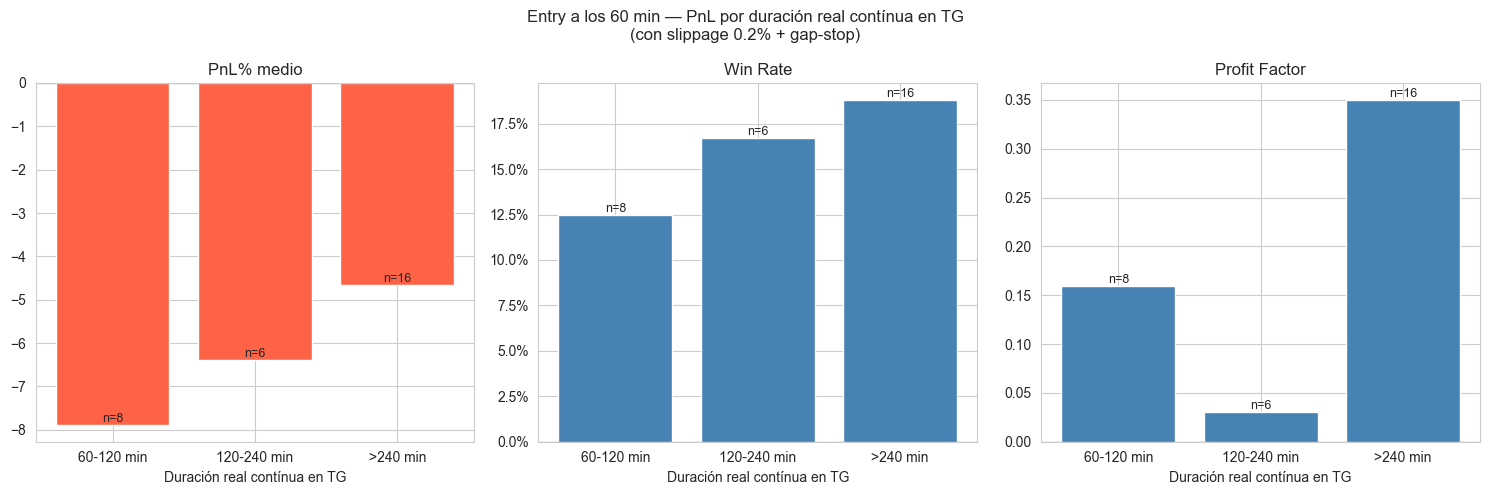

In [10]:
e60 = sim[(sim['entry_type'] == 'entry_60')].copy()

# Usar real_dur_min para los bins (duración real contínua, no span)
bins   = [0, 60, 120, 240, 2000]
labels = ['<60 min', '60-120 min', '120-240 min', '>240 min']
e60['dur_bucket'] = pd.cut(e60['real_dur_min'], bins=bins, labels=labels)

print("PnL por duración contínua en TG (entry a los 60 min con slippage y gap-stop):")
grp_list = []
for bucket in labels:
    sub = e60[e60['dur_bucket'] == bucket]
    if len(sub) == 0:
        continue
    st = robust_stats(sub)
    st['dur_bucket'] = bucket
    grp_list.append(st)
grp_df = pd.DataFrame(grp_list).set_index('dur_bucket')
print(grp_df[['n','mean_%','median_%','win_rate','stop_rate','wins5_%','profit_factor','max_dd_$']].to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, label in [
    (axes[0], 'mean_%',        'PnL% medio'),
    (axes[1], 'win_rate',      'Win Rate'),
    (axes[2], 'profit_factor', 'Profit Factor'),
]:
    vals = grp_df[col]
    colors = ['steelblue' if v >= 0 else 'tomato' for v in vals]
    ax.bar(grp_df.index.astype(str), vals, color=colors)
    for i, (idx, row_) in enumerate(grp_df.iterrows()):
        ax.text(i, vals.iloc[i], f"n={int(row_['n'])}", ha='center', va='bottom', fontsize=9)
    ax.set_title(label)
    ax.set_xlabel('Duración real contínua en TG')
    if col == 'win_rate':
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.axhline(0, color='black', linewidth=0.8)

plt.suptitle('Entry a los 60 min — PnL por duración real contínua en TG\n(con slippage 0.2% + gap-stop)')
plt.tight_layout()
plt.show()


## 8. Comparativa entry_0 vs entry_30 vs entry_60

Pares completos (3 entry types): 30 ticker-días  (90 trades)

Métricas robustas — base común:
           n  mean_%  median_%  win_rate  stop_rate  wins5_%  profit_factor  sharpe_ann  max_dd_$
entry                                                                                            
entry_0   30    6.98      -7.0     0.300      0.700     5.75           2.07        2.95    -143.2
entry_30  30   -0.21      -7.0     0.267      0.700    -0.62           0.97       -0.17    -246.6
entry_60  30   -5.87      -7.0     0.167      0.833    -5.88           0.24       -9.87    -420.2


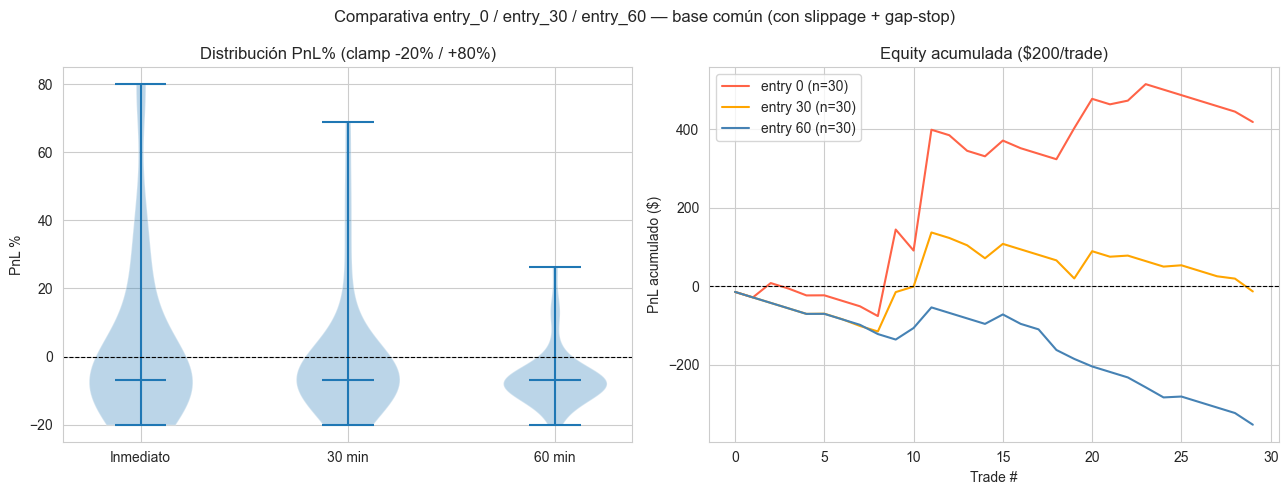

In [11]:
has_all = sim.groupby(['ticker','date'])['entry_type'].nunique() == 3
valid_pairs = has_all[has_all].index
sim_cmp = sim[sim.set_index(['ticker','date']).index.isin(valid_pairs)].copy()

print(f"Pares completos (3 entry types): {len(valid_pairs)} ticker-días  ({len(sim_cmp)} trades)")
print("\nMétricas robustas — base común:")
rows_cmp = []
for et in ['entry_0', 'entry_30', 'entry_60']:
    sub = sim_cmp[sim_cmp['entry_type'] == et]
    st  = robust_stats(sub)
    st['entry'] = et
    rows_cmp.append(st)
cmp_df = pd.DataFrame(rows_cmp).set_index('entry')
print(cmp_df[['n','mean_%','median_%','win_rate','stop_rate','wins5_%','profit_factor','sharpe_ann','max_dd_$']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Violin de distribución PnL (capped a -20%..+50% para visualización)
ax = axes[0]
data_plot = [
    sim_cmp[sim_cmp['entry_type']=='entry_0']['pnl_pct'].clip(-20, 80).values,
    sim_cmp[sim_cmp['entry_type']=='entry_30']['pnl_pct'].clip(-20, 80).values,
    sim_cmp[sim_cmp['entry_type']=='entry_60']['pnl_pct'].clip(-20, 80).values,
]
ax.violinplot(data_plot, positions=[1,2,3], showmedians=True)
ax.set_xticks([1,2,3])
ax.set_xticklabels(['Inmediato', '30 min', '60 min'])
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Distribución PnL% (clamp -20% / +80%)')
ax.set_ylabel('PnL %')

# Equity curves
ax2 = axes[1]
colors = {'entry_0': 'tomato', 'entry_30': 'orange', 'entry_60': 'steelblue'}
for et in ['entry_0', 'entry_30', 'entry_60']:
    sub = sim_cmp[sim_cmp['entry_type']==et].sort_values(['date','ticker'])
    equity = (sub['pnl_pct'] * CAPITAL / 100).cumsum()
    ax2.plot(range(len(equity)), equity.values,
             label=f"{et.replace('_',' ')} (n={len(sub)})", color=colors[et])
ax2.axhline(0, color='black', lw=0.8, ls='--')
ax2.set_title('Equity acumulada ($200/trade)')
ax2.set_xlabel('Trade #')
ax2.set_ylabel('PnL acumulado ($)')
ax2.legend()

plt.suptitle('Comparativa entry_0 / entry_30 / entry_60 — base común (con slippage + gap-stop)')
plt.tight_layout()
plt.show()


## 9. Impacto del threshold de `chg_first` en señal sustained (entry_60)

¿Filtrar por `chg_first >= X%` mejora los resultados dentro de entry_60?


PnL por threshold de chg_first (entry_60, con slippage + gap-stop):
          n  mean_%  median_%  win_rate  stop_rate  wins5_%  profit_factor
chg_thr                                                                   
10       30   -5.87      -7.0     0.167      0.833    -5.88           0.24
15       30   -5.87      -7.0     0.167      0.833    -5.88           0.24
20       30   -5.87      -7.0     0.167      0.833    -5.88           0.24
25       30   -5.87      -7.0     0.167      0.833    -5.88           0.24
30       28   -5.70      -7.0     0.179      0.821    -5.70           0.25
35       28   -5.70      -7.0     0.179      0.821    -5.70           0.25
40       27   -5.65      -7.0     0.185      0.815    -5.66           0.26
45       25   -6.07      -7.0     0.160      0.840    -6.07           0.22
50       23   -5.80      -7.0     0.174      0.826    -5.80           0.24
55       19   -5.28      -7.0     0.211      0.789    -5.28           0.30
60       17   -5.08      -7.0   

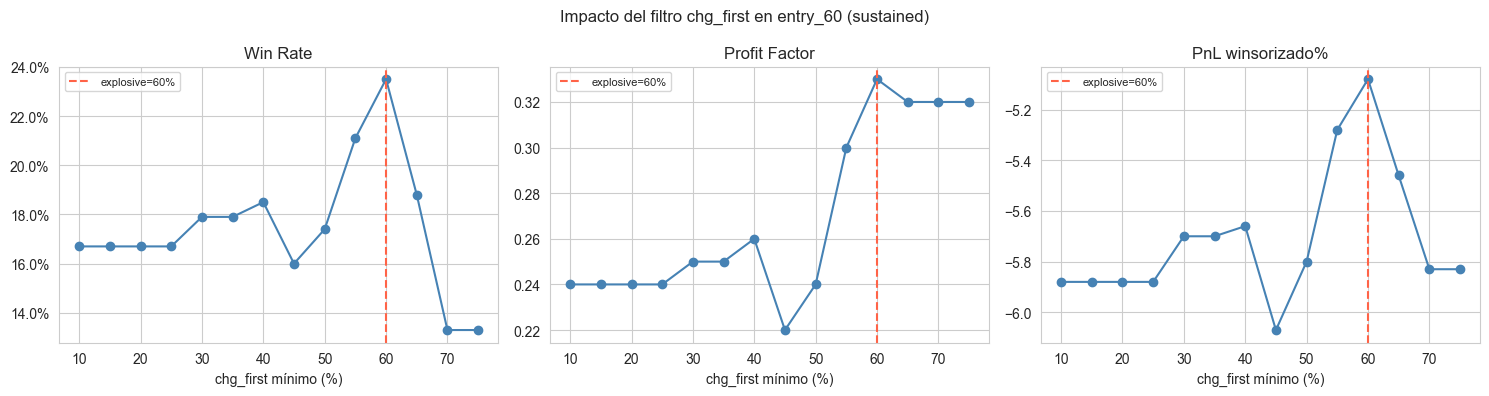

In [12]:
e60_all = sim[sim['entry_type'] == 'entry_60'].copy()

thresholds = range(10, 80, 5)
thr_rows = []
for thr in thresholds:
    sub = e60_all[e60_all['chg_first'] >= thr]
    if len(sub) < 5:
        continue
    st = robust_stats(sub)
    st['chg_thr'] = thr
    thr_rows.append(st)

thr_df = pd.DataFrame(thr_rows).set_index('chg_thr')
print("PnL por threshold de chg_first (entry_60, con slippage + gap-stop):")
print(thr_df[['n','mean_%','median_%','win_rate','stop_rate','wins5_%','profit_factor']].to_string())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in [
    (axes[0], 'win_rate',      'Win Rate'),
    (axes[1], 'profit_factor', 'Profit Factor'),
    (axes[2], 'wins5_%',       'PnL winsorizado%'),
]:
    ax.plot(thr_df.index, thr_df[col], marker='o', color='steelblue')
    ax.set_xlabel('chg_first mínimo (%)')
    ax.set_title(label)
    ax.axvline(EXPLOSIVE_CHG, color='tomato', ls='--', label=f'explosive={EXPLOSIVE_CHG:.0f}%')
    ax.legend(fontsize=8)
    if col == 'win_rate':
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.suptitle('Impacto del filtro chg_first en entry_60 (sustained)')
plt.tight_layout()
plt.show()


## 7b. Señal `explosive` — validación con duración real corregida

Filtro: `chg_first ≥ 60%` **y** `real_dur_min ≥ 120 min` (duración contínua corregida).
Esta es la regla implementada en producción en `hype_engine.py`.


Ticker-días con señal explosive: 15
Trades simulados (3 entry types): 45

Métricas robustas por entry type — señal explosive:
           n  mean_%  median_%  win_rate  stop_rate  wins5_%  profit_factor  sharpe_ann  max_dd_$
entry                                                                                            
entry_0   15   11.71      -7.0     0.267      0.733    11.71           2.60        3.68    -151.7
entry_30  15    3.60      -7.0     0.333      0.667     3.60           1.73        2.44    -130.6
entry_60  15   -3.98      -7.0     0.267      0.733    -3.98           0.41       -5.34    -201.4

Pares completos para Wilcoxon: 15
Wilcoxon signed-rank (explosive, entry_60>entry_0): stat=42.0  p=0.7452  (no significativo)


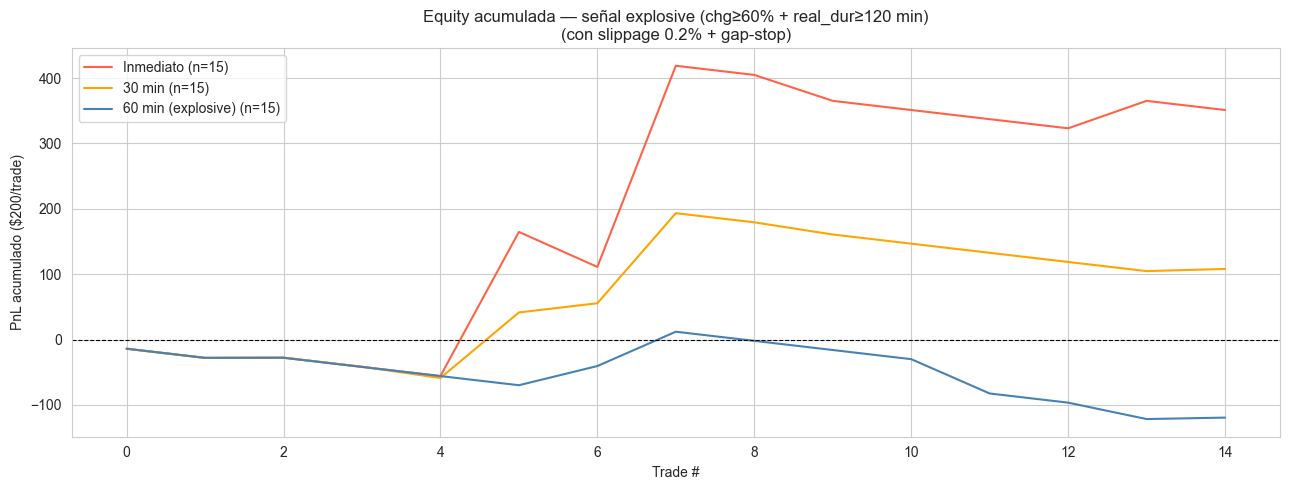

In [13]:
expl = sim[
    (sim['chg_first']    >= EXPLOSIVE_CHG) &
    (sim['real_dur_min'] >= EXPLOSIVE_DUR)
].copy()

n_days = expl[['ticker','date']].drop_duplicates()
print(f"Ticker-días con señal explosive: {len(n_days)}")
print(f"Trades simulados (3 entry types): {len(expl)}\n")

print("Métricas robustas por entry type — señal explosive:")
expl_rows = []
for et in ['entry_0', 'entry_30', 'entry_60']:
    sub = expl[expl['entry_type'] == et]
    if len(sub) == 0:
        continue
    st = robust_stats(sub)
    st['entry'] = et
    expl_rows.append(st)
expl_df = pd.DataFrame(expl_rows).set_index('entry')
print(expl_df[['n','mean_%','median_%','win_rate','stop_rate','wins5_%','profit_factor','sharpe_ann','max_dd_$']].to_string())

# Test pareado Wilcoxon para explosive
e0_ex  = expl[expl['entry_type']=='entry_0'].set_index(['ticker','date'])[['pnl_pct']]
e60_ex = expl[expl['entry_type']=='entry_60'].set_index(['ticker','date'])[['pnl_pct']]
paired_ex = e0_ex.join(e60_ex, lsuffix='_0', rsuffix='_60').dropna()
print(f"\nPares completos para Wilcoxon: {len(paired_ex)}")
if len(paired_ex) >= 10:
    diffs_ex = paired_ex['pnl_pct_60'] - paired_ex['pnl_pct_0']
    stat_ex, p_ex = wilcoxon(diffs_ex, alternative='greater')
    print(f"Wilcoxon signed-rank (explosive, entry_60>entry_0): stat={stat_ex:.1f}  p={p_ex:.4f}  "
          f"({'SIGNIFICATIVO' if p_ex < 0.05 else 'no significativo'})")

# Equity curve
fig, ax = plt.subplots(figsize=(13, 5))
for et, color, label in [('entry_0','tomato','Inmediato'), ('entry_30','orange','30 min'),
                          ('entry_60','steelblue','60 min (explosive)')]:
    sub = expl[expl['entry_type']==et].sort_values(['date','ticker'])
    equity = (sub['pnl_pct'] * CAPITAL / 100).cumsum()
    ax.plot(range(len(equity)), equity.values, label=f"{label} (n={len(sub)})", color=color)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_title('Equity acumulada — señal explosive (chg≥60% + real_dur≥120 min)\n(con slippage 0.2% + gap-stop)')
ax.set_xlabel('Trade #')
ax.set_ylabel('PnL acumulado ($200/trade)')
ax.legend()
plt.tight_layout()
plt.show()


## 10. Resumen ejecutivo

In [14]:
print('=' * 70)
print('RESUMEN — SIMULACIÓN REACTIVA v2 (mismo día del burst)')
print('=' * 70)
print(f'Stop loss: {STOP_PCT*100:.0f}%  |  Slippage: {SLIPPAGE_PCT*100:.1f}%  |  Gap-stop: activo  |  Capital: ${CAPITAL}/trade')
print(f'Rango datos: {snaps["date"].min()} → {snaps["date"].max()}')
print()

# Sustained
sus = sim[sim['entry_type']=='entry_60'].copy()
st_sus = robust_stats(sus)
print(f'SEÑAL SUSTAINED (real_dur ≥ {SUSTAINED_DUR} min, n={st_sus["n"]}):')
print(f'  Mean PnL:       {st_sus["mean_%"]:+.2f}%   Median: {st_sus["median_%"]:+.2f}%')
print(f'  Win rate:       {st_sus["win_rate"]:.0%}   Stop rate: {st_sus["stop_rate"]:.0%}')
print(f'  Wins5 (wins.):  {st_sus["wins5_%"]:+.2f}%  Profit factor: {st_sus["profit_factor"]:.2f}x')
print(f'  Sharpe anual:   {st_sus["sharpe_ann"]:.2f}   Max drawdown: ${st_sus["max_dd_$"]:.0f}')
print()

# Explosive
st_ex = robust_stats(expl[expl['entry_type']=='entry_60']) if len(expl) else {}
if st_ex:
    print(f'SEÑAL EXPLOSIVE (chg≥{EXPLOSIVE_CHG:.0f}% + real_dur≥{EXPLOSIVE_DUR} min, n={st_ex["n"]}):')
    print(f'  Mean PnL:       {st_ex["mean_%"]:+.2f}%   Median: {st_ex["median_%"]:+.2f}%')
    print(f'  Win rate:       {st_ex["win_rate"]:.0%}   Stop rate: {st_ex["stop_rate"]:.0%}')
    print(f'  Wins5 (wins.):  {st_ex["wins5_%"]:+.2f}%  Profit factor: {st_ex["profit_factor"]:.2f}x')
    print(f'  Sharpe anual:   {st_ex["sharpe_ann"]:.2f}   Max drawdown: ${st_ex["max_dd_$"]:.0f}')
print()

print('LIMITACIONES:')
total_u = len(universe)
with_bars_u = universe['has_bars'].sum() if 'has_bars' in universe.columns else '?'
print(f'  · Cobertura barras: {with_bars_u}/{total_u} ticker-días ({int(with_bars_u)/total_u:.0%})')
print(f'  · El period incluye Liberation Day (7-10 abr): mercado anormal puede inflar outliers')
print(f'  · Precio entry = snapshot Finviz (5 min delay) + slippage modelado simplificado')
print(f'  · Sin comisiones explícitas (SEC/TAF fees ~$0.003/trade en small-caps)')
print(f'  · Media dominada por outliers — usar "wins5_%" como métrica central')
print(f'  · Sample explosive n≈{st_ex.get("n","?")}: insuficiente para estabilidad estadística')


RESUMEN — SIMULACIÓN REACTIVA v2 (mismo día del burst)
Stop loss: 7%  |  Slippage: 0.2%  |  Gap-stop: activo  |  Capital: $200/trade
Rango datos: 2026-03-24 → 2026-04-29

SEÑAL SUSTAINED (real_dur ≥ 60 min, n=30):
  Mean PnL:       -5.87%   Median: -7.00%
  Win rate:       17%   Stop rate: 83%
  Wins5 (wins.):  -5.88%  Profit factor: 0.24x
  Sharpe anual:   -9.87   Max drawdown: $-420

SEÑAL EXPLOSIVE (chg≥60% + real_dur≥120 min, n=15):
  Mean PnL:       -3.98%   Median: -7.00%
  Win rate:       27%   Stop rate: 73%
  Wins5 (wins.):  -3.98%  Profit factor: 0.41x
  Sharpe anual:   -5.34   Max drawdown: $-201

LIMITACIONES:
  · Cobertura barras: 228/378 ticker-días (60%)
  · El period incluye Liberation Day (7-10 abr): mercado anormal puede inflar outliers
  · Precio entry = snapshot Finviz (5 min delay) + slippage modelado simplificado
  · Sin comisiones explícitas (SEC/TAF fees ~$0.003/trade en small-caps)
  · Media dominada por outliers — usar "wins5_%" como métrica central
  · Sample